In [85]:
import os
from time import time

import cv2

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input


In [86]:
def display_history(history, names, title):
    plt.figure()
    plt.title(title)
    for name in names:
        plt.plot(history.history[name], label=name)
    # plt.plot(history.history[names[0]], label=names[0])
    # plt.plot(history.history[names[1]], label=names[1])
    plt.xlabel("Epochs")
    plt.ylabel(names[0])
    plt.legend()
    plt.show()

def predict_random(model, data_x, data_y, image_size = None):
    choose = np.random.randint(0, data_x.shape[0])
    if image_size is None:
        plt.imshow(data_x[choose])
    else:
        plt.imshow(data_x[choose].reshape(*image_size))
    predictions = model.predict(data_x)
    plt.title(f'Predicted Object: {np.argmax(predictions[choose])} | Real Object: {np.argmax(data_y[choose])}')
    # plt.title(f'Predicted Object: {int_to_str[np.argmax(predictions[choose])]} | Real Object: {int_to_str[np.argmax(data_y[choose])]}')

def predict(model, X_train, y_train, X_test, y_test, batch_size=64, epochs=40, val_split=0.2, image_size = None):
    # history = model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test), callbacks=callbacks)
    loss_labels = ['loss', 'val_loss']
    acc_labels = ['accuracy', 'val_accuracy']
    if isinstance(val_split, float):
        if val_split == 0: 
            loss_labels = loss_labels[:1]
            acc_labels = acc_labels[:1]
        history = model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs, validation_split=val_split)
    elif isinstance(val_split, tuple):
        history = model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs, validation_data=val_split)
    display_history(history, loss_labels, "Loss")
    display_history(history, acc_labels, "Accuracy")
    model.evaluate(X_test, y_test)
    predict_random(model, X_test, y_test, image_size)

## Prac 07.1

In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.


### Step 1
Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class?


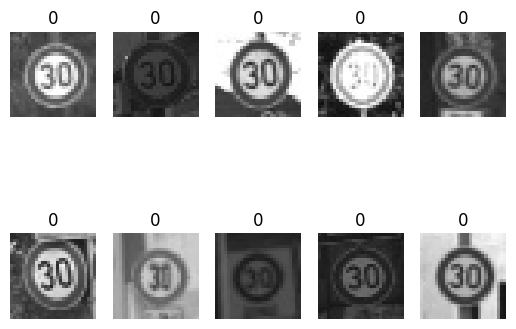

In [87]:
folder = 'data/subset_homework/'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

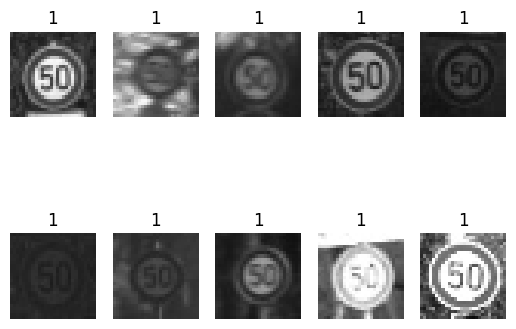

In [88]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [89]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


In [90]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

image_size = images.shape[1:]
print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


In [91]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.011019706726074219


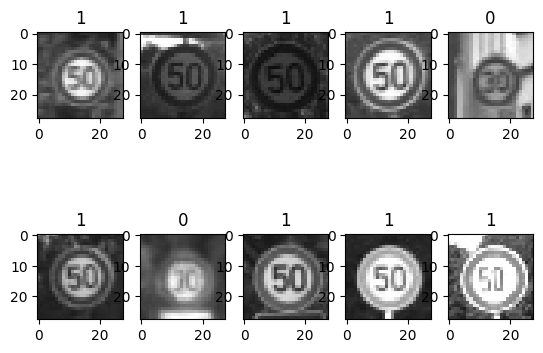

In [92]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])


### Step 2
Run the training with one single neuron (as we did in the lecture). What accuracy can you achieve?


In [93]:
inputs = Input(shape=(pixels.shape[1], ))
inputs = Dense(pixels.shape[1], activation="linear")(inputs)
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.compile(optimizer ='adam', loss = 'mean_squared_error', metrics=["accuracy"])

model.summary()
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_22CLONE            │ (None, 784)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.4638 - loss: 0.4459
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - accuracy: 0.5076 - loss: 0.3104
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.5506 - loss: 0.2747
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - accuracy: 0.6004 - loss: 0.2409
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.6494 - loss: 0.2173
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.6951 - loss: 0.1983
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - accuracy: 0.7313 - loss: 0.1797
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - accuracy: 0.7606 - loss: 0.1674
Epoch 9/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.7821 - loss: 0.1547
Epoch 10/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.8112 - loss: 0.1449
Epoch 11/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.8237 - loss: 0.1363
Epoch 12/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step

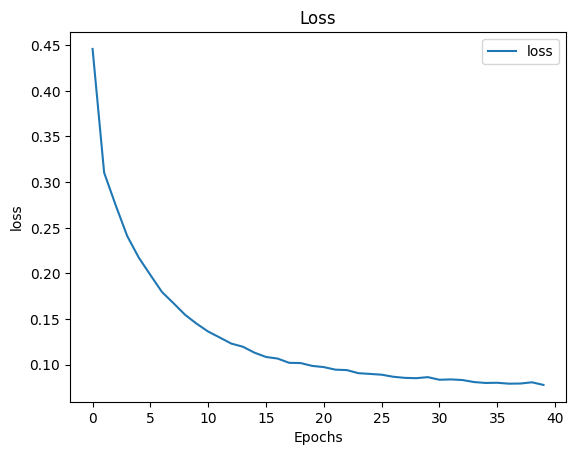

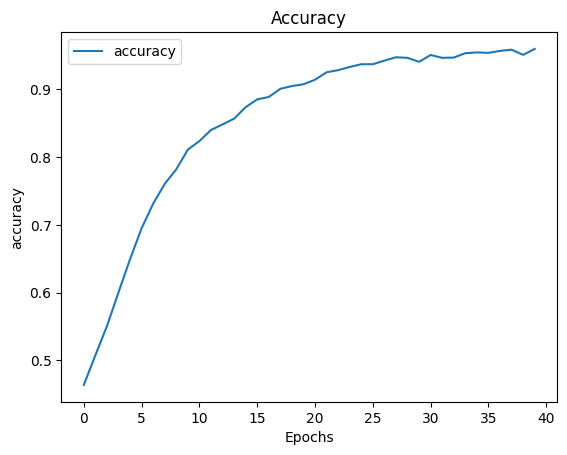

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step - accuracy: 0.9597 - loss: 0.0766
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step


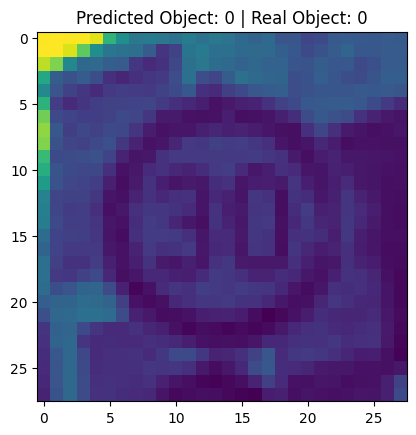

In [94]:
predict(model, pixels, labels, pixels, labels, batch_size=64, epochs=40, val_split=0.0, image_size=image_size)

In [95]:
# history = model.fit(pixels, labels, epochs=10, batch_size=32)

In [96]:
# idx = 50
# pred = model.predict(pixels[idx:idx+1, ...])
# print(pred, labels[idx])

In [97]:
# # Run it on the entire dataset
# predictions = model.predict(pixels).squeeze()
# predictions = predictions > 0.5

In [98]:
# correct = 0
# for prediction, label in zip(predictions, labels):
#     if prediction == label:
#         correct = correct + 1

# print('Accuracy', correct/len(labels))


### Step 3
Make further modifications to improve the accuracy (e.g. add more neurons, more layers, etc.). What is the maximum accuracy you can achieve?

# Prac 07.2

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

In [99]:
# Load the training labels
root = '...' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples =

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = 
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

SyntaxError: invalid syntax (479246307.py, line 6)

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [ ]:
# Extract class identifiers
# Hint: Check the csv 
ids =

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

In [ ]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
* Are there any classes that are (significantly) over-represented or under-represeneted?

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?